# Aula 9


# Autoencoders - Aplicações


### Eduardo Lobo Lustosa Cabral

## 1. Objetivos

Apresentar duas aplicações de autoencoders:

1. Criar um autoencoder para eliminar ruído de imagens.

2. Criar um autoencoder para detectar anomalias.

Observa-se que os autoencoders podem ser usaddos para outras aplicações, tais como:

1. Codificação de dados;
2. Redução de dimensionalidade;
3. Criação de modelos universais.

Essa aula é baseado no notebook https://www.tensorflow.org/tutorials/generative/autoencoder?hl=pt-br.


### Importação das bilbiotecas necessárias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
print(tf.__version__)

2.19.0


## 2. Eliminação de ruídos em imagens

Um autoencoder pode ser treinado para eliminar ruídos em imagens. De fato essa técnica é bastante usada e eliminação de ruídos em imagens é outra aplicação de autoencoders.

Nesse caso o autoencoder é treinado com as imagens de entrada com ruído e as imagens de saída sendo as imagens originais sem ruído. Dessa forma, o autoencoder aprende a subtrair o ruído das imagens e gerar imagens de melhor qualidade.

Observa-se que o autoencoder não recebe a imagem original na sua entrada, mas é esperado que ele regenere a imagem original sem ruído na saída.

Na Figura 6 é apresentado um esquema de um autoencoder treinado para receber imagens com ruídos e gerar a imagem sem rúido.

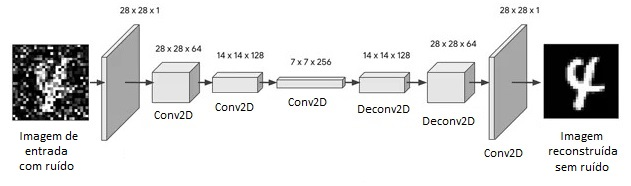
<center>Figura 6 - Esquema de um autoencoder para eliminar ruído de imagens.</center>

Para exemplificar essa aplicação de um autoencoder vamos utilizar o conjunto de dígitos MNIST.

### 2.1 Carregar e processar dados

A célula abaixo carrega o conjunto de dígitos MNIST da coleção do Keras.

In [ ]:
(x_train_orig, y_train), (x_test_orig, y_test) = tf.keras.datasets.mnist.load_data()

print('Dimensão dos dados de entrada de treinamento =', x_train_orig.shape)
print('Dimensão dos dados de entrada de teste =', x_test_orig.shape)
print('Dimensão dos dados de saída de treinamento =', y_train.shape)
print('Dimensão dos dados de saída de teste =', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensão dos dados de entrada de treinamento = (60000, 28, 28)
Dimensão dos dados de entrada de teste = (10000, 28, 28)
Dimensão dos dados de saída de treinamento = (60000,)
Dimensão dos dados de saída de teste = (10000,)


Vamos redimensionar as imagens para que tenham dimensão de 32x32 pixels. Isso é feito para garantir que as dimensões dos tensores quando as imagens forem reduzidas pelo codificador sejam sempre números inteiros.  

In [ ]:
from skimage.transform import resize

x_train = resize(x_train_orig, (60000, 32,32), anti_aliasing=True)
x_test = resize(x_test_orig, (10000, 32,32), anti_aliasing=True)

print('Dimensão dos dados de entrada de treinamento =', x_train.shape)
print('Dimensão dos dados de entrada de teste =', x_test.shape)

Dimensão dos dados de entrada de treinamento = (60000, 32, 32)
Dimensão dos dados de entrada de teste = (10000, 32, 32)


In [ ]:
print(np.min(x_train), np.max(x_train), np.max(x_train_orig))

0.0 1.0 255


- Observe que a função `resize` da biblioteca SkiImage já realiza a normalização dos pixels das imagens para valores reais entre 0 e 1.

Vamos usar um autoencoder com camadas convolucionais, assim, não precisamos transformar as imagens em vetores.

### 2.2 Introdução de ruído nas imagens

As imagens de entrada são as imagens originais adicionadas de ruído gaussiando. Vamos testar diferentes desvios padrões para verificar o desempenho do autoencoder em eliminar ruídos.

In [ ]:
# Número de exemplos de treinamento e teste
m_train = x_train.shape[0]
m_test = x_test.shape[0]

# Define desvio padrão do ruído
noise_std = 0.5

# Adiciona ruído na simagens de treinamento e teste
x_train_noise = x_train + noise_std*np.random.randn(m_train, 32, 32)
x_test_noise = x_test + noise_std*np.random.randn(m_test, 32, 32)

# Acerta pixles com valores maiores do que 1 e menores do que 0
x_train_noise = np.clip(x_train_noise, 0.0, 1.0)
x_test_noise = np.clip(x_test_noise, 0.0, 1.0)

#### Gráficos de alguns exemplos de imagens originais e com ruído

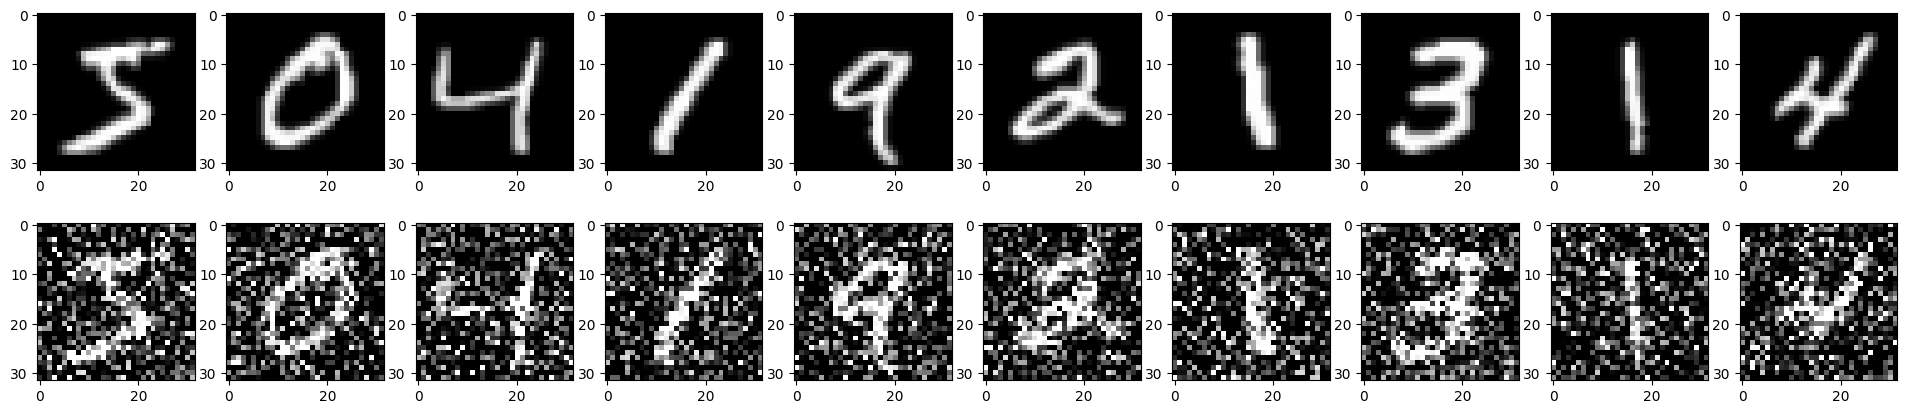

In [ ]:
image_dim = (32, 32)

# Mostra imagens originais e reconstruídas
f, pos = plt.subplots(2, 10, figsize=(24, 5))
for i in range(10):
    pos[0,i].imshow(x_train[i], cmap='gray')
    pos[1,i].imshow(x_train_noise[i], cmap='gray')
plt.show()

- Observa-se que o ruído inserido nas imagens é significativo, mas ainda é possivel identificar os dígitos.


### 2.3 Adicão do eixo de cores nas imagens

As camadas convolucionais do Keras esperam receber imagens coloridas, ou seja, imagens com 3 eixos. Como as imagens de dígitos MNIST são em tons de cinza, devemos adicionar um quarto eixo aos tensores de imagens com dimensão 1.

In [ ]:
# Adinção do eixo de cores nas imagens
x_train_4 = np.expand_dims(x_train, axis=3)
x_test_4 = np.expand_dims(x_test, axis=3)
x_train_noise_4 = np.expand_dims(x_train_noise, axis=3)
x_test_noise_4 = np.expand_dims(x_test_noise, axis=3)

# Dimensão dos tensores de imagens
print('Dimensão do tensor de imagens de treinamento:', x_train_4.shape)
print('Dimensão do tensor de imagens de teste:', x_test_4.shape)
print('Dimensão do tensor de imagens com ruído de treinamento:', x_train_noise_4.shape)
print('Dimensão do tensor de imagens com ruído de teste:', x_test_noise_4.shape)

Dimensão do tensor de imagens de treinamento: (60000, 32, 32, 1)
Dimensão do tensor de imagens de teste: (10000, 32, 32, 1)
Dimensão do tensor de imagens com ruído de treinamento: (60000, 32, 32, 1)
Dimensão do tensor de imagens com ruído de teste: (10000, 32, 32, 1)


### 2.4 Configuração do autoencoder

Nesse exemplo vamos utilizar um autoencoder com camadas convolucionais e com um grande número de parâmetros em relação ao número total de pixels das imagens.

A arquitetura usada no codificador é a seguinte:

- Camada convolucional com 32 filtros, dimensão dos filtros=3x3, stride=2, função de ativação LeReLu, padding=same;
- Camada convolucional com 32 filtros, dimensão dos filtros=3x3, stride=2, função de ativação LeReLu, padding=same;
- Camada convolucional com 32 filtros, dimensão dos filtros=3x3, stride=2, função de ativação LeReLu, padding=same.

A arquitetura usada no decodificador é a seguinte:

- Camada de deconvolução com 16 filtros, dimensão dos filtros=3x3, stride=2, função de ativação ReLu, padding=same;
- Camada de deconvolucão com 8 filtros, dimensão dos filtros=3x3, stride=2, função de ativação ReLu, padding=same
- Camada de deconvolucão com 4 filtros, dimensão dos filtros=3x3, stride=2, função de ativação ReLu, padding=same
- Camada convolucional com 1 filtro, dimensão dos filtros=1x1, stride=1, função de ativação sigmode, padding=same.

Note que o objetivo desse autoencoder é eliminar ruído de imagens e não obter um espaço latente compacto para representar as imagens. Assim, não é importante que o número de características do código seja muito menor do que o número de pixels das imagens originais.

In [ ]:
# Importa camadas necessárias
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, LayerNormalization, LeakyReLU, Input

# Configura codificador
encoder = Sequential()
encoder.add(Input(shape=(32,32,1)))
encoder.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation=LeakyReLU()))
encoder.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation=LeakyReLU()))
encoder.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation=LeakyReLU()))
encoder.add(LayerNormalization())

# Configura decodificador
decoder = Sequential()
decoder.add(Input(shape=(4,4,32)))
decoder.add(Conv2DTranspose(16, kernel_size=3, strides=2, padding='same', activation='gelu'))
decoder.add(Conv2DTranspose(8, kernel_size=3, strides=2, padding='same', activation='gelu'))
decoder.add(Conv2DTranspose(4, kernel_size=3, strides=2, padding='same', activation='gelu'))
decoder.add(Conv2D(1, kernel_size=1, strides=1, padding='same', activation='sigmoid'))

# Configura autoencoder
autoencoder = Sequential([encoder, decoder])

# Sumario do codificador
print('Codificador:')
print(encoder.summary(),'\n\n')

# Sumario do decodificador
print('Decodificador:')
print(decoder.summary(),'\n\n')

# Sumario do autoencoder
print('Autoencoder:')
print(autoencoder.summary())

Codificador:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 4, 4, 32)       │            64 │
│ (LayerNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,880 (73.75 KB)

 Trainable params: 18,880 (73.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 4, 4, 32)       │        18,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 1)      │         6,081 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,961 (97.50 KB)

 Trainable params: 24,961 (97.50 KB)

 Non-trainable params: 0 (0.00 B)

None


- A saída do codificar é um tensor de dimensão 4x4x32, que possui 512 elementos. Note que as imagens originais com dimensão 28x28 possuem 784 pixels, portanto, o espaço latente consiste de uma pequena redução de cerca de 1,5 vezes em relação às imagens originais.

### 2.5 Compilação do autoencoder

Vamos compilar o autoencoder com a seguinte configuração:

- Otimizador: Adam com taxa de aprendizado de 0.001;
- Função de custo: "binary cross entropy"
- Métrica: "binary_accuracy"

In [ ]:
# Define otimizador Adam
adam = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compilação do autoencoder
autoencoder.compile(optimizer=adam, loss='binary_crossentropy', metrics=['mae'])

### 2.6 Treinamento do autoencoder

Vamos treinar o autoencoder usando 50 épocas e lotes de 500 elementos.

In [ ]:
results = autoencoder.fit(x_train_noise_4, x_train_4, epochs=50, batch_size=500, validation_data=(x_test_noise_4, x_test_4))

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.5278 - mae: 0.3381 - val_loss: 0.1726 - val_mae: 0.0749
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1621 - mae: 0.0664 - val_loss: 0.1409 - val_mae: 0.0500
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1393 - mae: 0.0486 - val_loss: 0.1335 - val_mae: 0.0447
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1335 - mae: 0.0442 - val_loss: 0.1304 - val_mae: 0.0422
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1309 - mae: 0.0421 - val_loss: 0.1284 - val_mae: 0.0406
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1290 - mae: 0.0407 - val_loss: 0.1271 - val_mae: 0.0397
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1278 - mae: 0.0398 - val_loss: 0.1262 - val_mae: 0.0389
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1268 - mae: 0.0390 - val_loss: 0.1253 - val_mae: 0.0380
Epoch 9/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - 

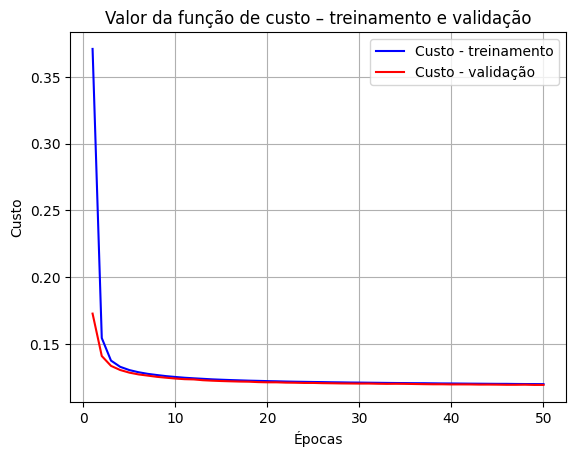

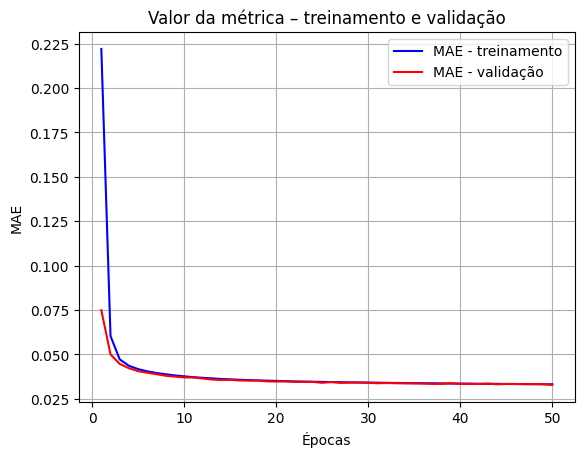

In [ ]:
def plot_train(history):
    history_dict = history.history

    # Salva custos, métricas e epocas em vetores
    custo = history_dict['loss']
    acc = history_dict['mae']
    val_custo = history_dict['val_loss']
    val_acc = history_dict['val_mae']

    # Cria vetor de épocas
    epocas = range(1, len(custo) + 1)

    # Gráfico dos valores de custo
    plt.plot(epocas, custo, 'b', label='Custo - treinamento')
    plt.plot(epocas, val_custo, 'r', label='Custo - validação')
    plt.title('Valor da função de custo – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Custo')
    plt.grid()
    plt.legend()
    plt.show()

    # Gráfico dos valores da métrica
    plt.plot(epocas, acc, 'b', label='MAE - treinamento')
    plt.plot(epocas, val_acc, 'r', label='MAE - validação')
    plt.title('Valor da métrica – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('MAE')
    plt.grid()
    plt.legend()
    plt.show()

plot_train(results)

### 2.7 Avaliação do AE

Para avaliar o desempenho do AE vamos calcular o valor da função de custo e da métrica.

In [ ]:
# Calcula função de custo e métrica
autoencoder.evaluate(x_train_noise_4, x_train_4)
autoencoder.evaluate(x_test_noise_4, x_test_4)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.1194 - mae: 0.0328
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1182 - mae: 0.0327


[0.11922905594110489, 0.03283780813217163]

-  Observa-se que o erro absoluto médio é da ordem de 0.036 tanto para os dados de treinamento como de teste. Esse resultado não é muito bom, tendo em vista o fato do espaço latente ter quase o mesmo número de características do que as imagens originais tem de pixels. Porém, nota-se que a amplitude do ruído presente nas imagens de entrada é significativa.


### 2.8 Espaço latente das imagens

O espaço latente de cada imagem é um tensor de dimensão 4x4x32, assim, ele pode ser visto como sendo composto por 32 imagens de dimensão 4x4.

Vamos visualizar a representação latente de algumas imagens.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Dimensão do espaço latente: (10000, 4, 4, 32)


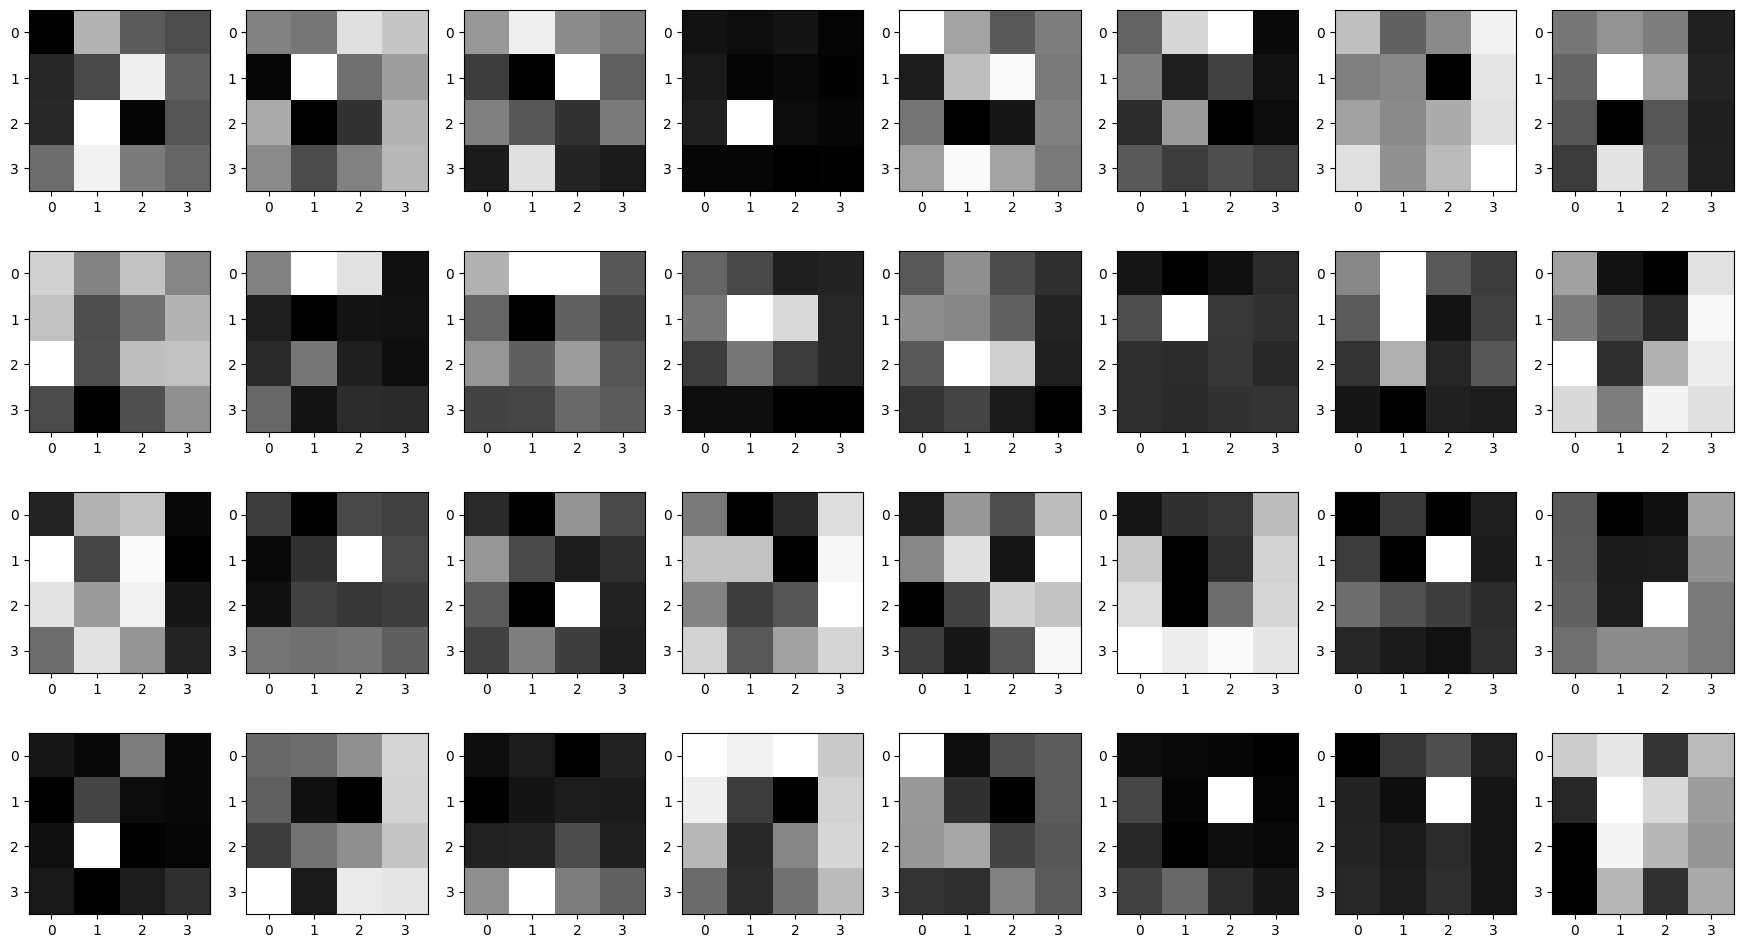

In [ ]:
# Calcula códigos das imagens de teste
code = encoder.predict(x_test_noise_4)
print('Dimensão do espaço latente:', code.shape)

# Seleciona imagem do conjunto de teste
index = 0

# Mostra canais do espaço latente
cont = 0
f, pos = plt.subplots(4, 8, figsize=(22, 12))
for i in range(4):
    for j in range(8):
        pos[i,j].imshow(code[index,:,:,cont], cmap='gray')
        cont += 1
plt.show()

- Obviamente não é possível analisar esses dados, pois eles somente tem algum significado para o decodificador.

- Observa-se que cada imagem de dimensão 4x4 do espaço latente representa a presença (pixel mais claro) ou não (pixel mais escuro) de uma determinada característica em 16 regiões diferentes das imagens.

### 2.9 Comparação das saídas previstas pelo autoencoder com as imagens sem ruído

As saídas previstas pelo autoencoder representam como são reconstruídos os dados de entrada a partir da representação latente dos dados de entrada.

Vamos reconstruir as primeras 10 imagens de teste a partir das representações latentes calculadas no item anterior e visualizá-las junto com as imagens originais.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


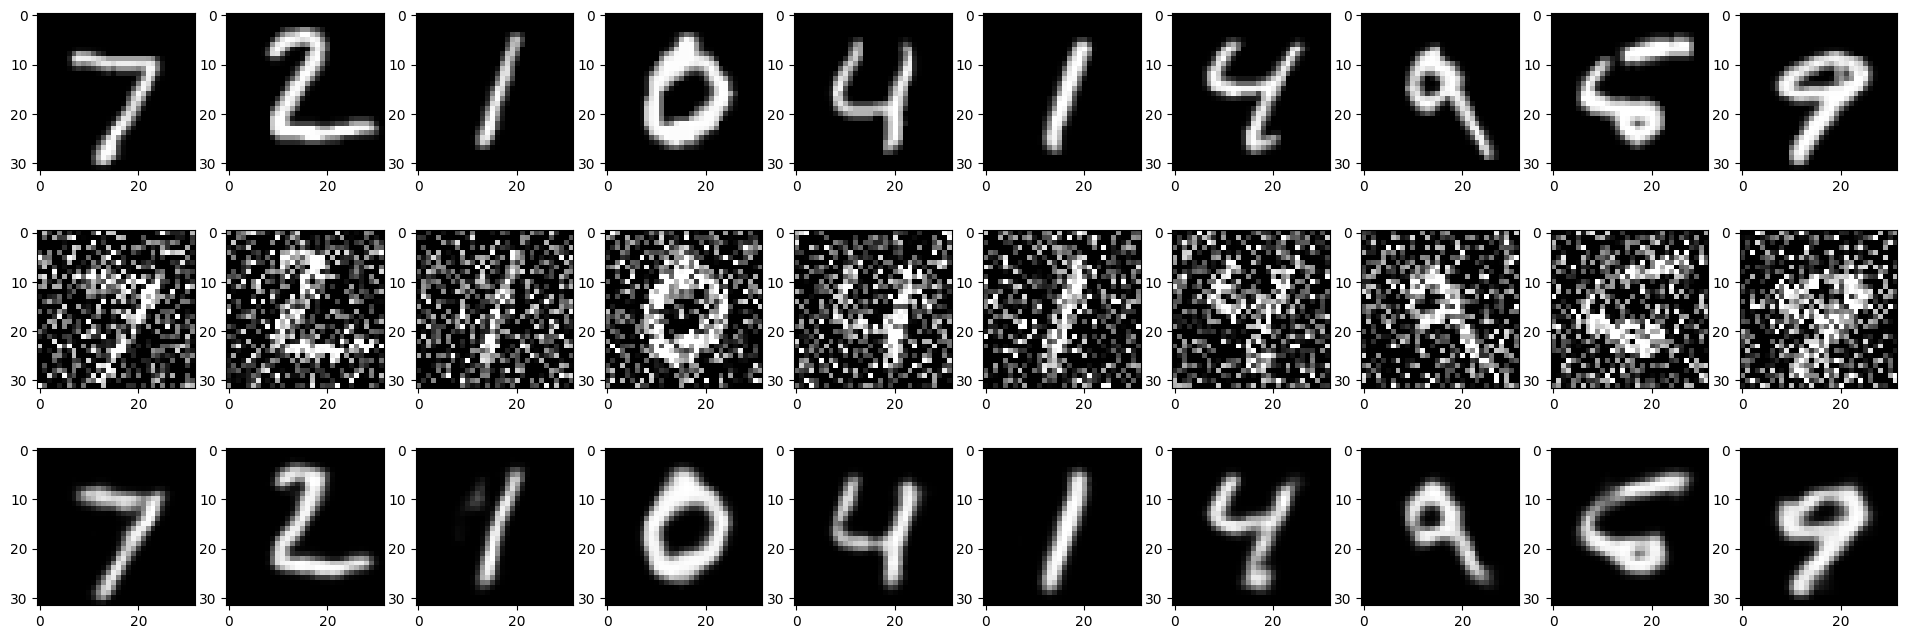

In [ ]:
# Reconstrução das imagens usando o espaço latente e o decodificador
x_prev = decoder.predict(code)

# Mostra imagens originais e reconstruídas
f, pos = plt.subplots(3, 10, figsize=(24, 8))
for i in range(10):
    img_prev = np.reshape(x_prev[i], (32, 32))
    pos[0,i].imshow(np.squeeze(x_test_4[i]), cmap='gray')
    pos[1,i].imshow(np.squeeze(x_test_noise_4[i]), cmap='gray')
    pos[2,i].imshow(np.squeeze(img_prev), cmap='gray')
plt.show()

- Observe que as imagens reconstruídas são muito semelhantes às originais.

- Pode-se concluir que o autoencoder apresenta um desempenho muito bom mesmo com a grand eamplitude do reúid presente nas imagens.

- É interessante analisar a influência da amplitude do ruído na qualidade das imagens reconstruídas.


## 3. Detecção de anomalias


Neste exemplo, vamos treinar um autoencoder para detectar anomalias em sinais de eletrocardiograma usando o conjunto de dados ECG5000 (http://www.timeseriesclassification.com/description.php?Dataset=ECG5000). Este conjunto de dados contém 5.000 eletrocardiogramas, cada um com 140 amostras.

Nesse exemplo usaremos uma versão simplificada do conjunto de dados, onde cada exemplo é rotulado como `0` (correspondendo a um ritmo anormal) ou` 1` (correspondendo a um ritmo normal). O objetivo é identificar os ritmos anormais.

**Observação:** esse conjunto de dados é rotulado, portanto, pode ser usado como um problema de aprendizado supervisionado. Porém, o objetivo deste exemplo é ilustrar o conceito de detecção de anomalias que pode ser aplicado a conjuntos de dados maiores, onde não há rótulos disponíveis (por exemplo, se tiver milhares de ritmos normais e apenas um pequeno número de ritmos anormais).

Um autencoder é treinado para minimizar o erro de reconstrução. Assim, se for desejado que o autoencoder detecte anomalias, então, deve-se treiná-lo apenas com eletrocardiogrmas normais e, utilizá-lo para reconstruir todos os dados. A hipótese é que os ritmos anormais terão maior erro de reconstrução. Dessa forma, é possível classificar um ritmo como uma anomalia se o erro de reconstrução ultrapassar um determinado limiar.

### 3.1 Carregar e processar dados

Os dados estão disponíveis no TensorFlow e estão em um CSV. Vamos utilizar o Pandas para carregar os dados.

In [ ]:
# Importa Pandas
import pandas as pd

# Carrega dados em um DataFrame
dataframe = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)

# Salva valores do DataFrame em tensor Numpy
raw_data = dataframe.values

# Dimensão dos dados
print(raw_data.shape)

# Mostra 5 primeiras linhas do DataFrame
dataframe.head()

(4998, 141)


,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


- Observe que cada linha do DataFrame é um exame de eletrocardiograma com 140 amostras.

- A última coluna do DataFrame é a clasisficação do exame.

Vamos analisar a estatísticas dos dados.

In [ ]:
dataframe.describe().T

,count,mean,std,min,25%,50%,75%,max
0,4998.0,-0.262502,1.152450,-6.729499,-1.004220,-0.297541,0.499909,4.966414
1,4998.0,-1.649828,1.445542,-7.090374,-2.701936,-1.661892,-0.677998,3.479689
2,4998.0,-2.492623,1.386457,-5.132459,-3.668585,-2.586129,-1.514187,2.660597
3,4998.0,-3.119754,1.302921,-5.363241,-4.227337,-3.388210,-2.235690,1.899798
4,4998.0,-3.167656,1.104535,-5.375715,-4.007630,-3.469899,-2.531153,2.147015
...,...,...,...,...,...,...,...,...
136,4998.0,-0.835173,2.056296,-4.880460,-2.868603,-0.195151,0.945027,3.432519
137,4998.0,-0.642739,1.859409,-5.496107,-2.154560,-0.194423,0.951621,3.579448
138,4998.0,-0.487667,1.831088,-5.880890,-1.658289,-0.160262,1.002628,4.425976
139,4998.0,-0.706574,1.414414,-6.092227,-1.596809,-0.568443,0.271635,7.402103


Separação das saídas das entradas e divisão dos dados em conjuntos de treinamento e validação.

In [ ]:
# Importa função para dividir dados
from sklearn.model_selection import train_test_split

# Separa as saídas
labels = raw_data[:, -1]

# Separa as entradas
data = raw_data[:, 0:-1]

# Divide dados em conjuntos de treinamento e validação
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.15, random_state=21)

print('Dimensão do tensor de dados de entrada de treinamento:', x_train.shape)
print('Dimensão do tensor de dados de entrada de teste:', x_test.shape)
print('Dimensão do tensor de dados de saída de treinamento:', y_train.shape)
print('Dimensão do tensor de dados de saída de treinamento:', y_test.shape)

Dimensão do tensor de dados de entrada de treinamento: (4248, 140)
Dimensão do tensor de dados de entrada de teste: (750, 140)
Dimensão do tensor de dados de saída de treinamento: (4248,)
Dimensão do tensor de dados de saída de treinamento: (750,)


Normalização dos dados no intervalo `[0,1]`.

In [ ]:
# Calcula valores mínimos e máximos de cada coluna
min_val = tf.reduce_min(x_train)
max_val = tf.reduce_max(x_train)

# Normalizaçãa das entradas
x_train = (x_train - min_val) / (max_val - min_val)
x_test = (x_test - min_val) / (max_val - min_val)

# Transformação em números reais
x_train = tf.cast(x_train, tf.float32)
x_test = tf.cast(x_test, tf.float32)

Vamos treinar o autoencoder usando somente os eletrocardiogramas normais, que são rotulados com saída igual a 1. Dessa forma temos que separa os exames normais dos com problema.

In [ ]:
# Transforma saídas em variáveis bolleanas
y_train = y_train.astype(bool)
y_test = y_test.astype(bool)

# Dados de entrada com exames normais
x_train_normal = x_train[y_train]
x_test_normal = x_test[y_test]

# Dados de entrada com exames com problemas
x_train_anormal = x_train[~y_train]
x_test_anormal = x_test[~y_test]

Gráfico de ECG normal.

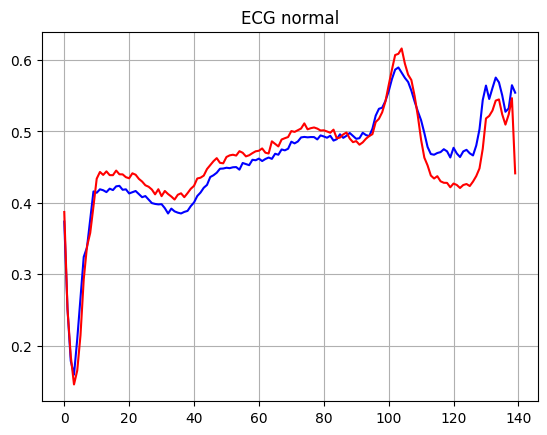

In [ ]:
plt.grid()
plt.plot(np.arange(140), x_train_normal[0], 'b')
plt.plot(np.arange(140), x_train_normal[10], 'r')
plt.title("ECG normal")
plt.show()

GRáfico de ECG anormal.

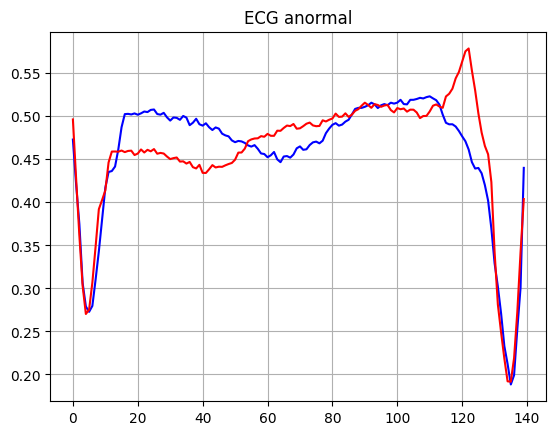

In [ ]:
plt.grid()
plt.plot(np.arange(140), x_train_anormal[0], 'b')
plt.plot(np.arange(140), x_train_anormal[20], 'r')
plt.title("ECG anormal")
plt.show()

### 3.2 Configuração do autoencoder

Vamos usar camadas densas e modelos sequenciais para configurar o codificador, o decoficador e o autoencoder.

In [ ]:
# Importa classe de modelos e camadas
from tensorflow.keras import layers
from tensorflow.keras import models

# Define dimensões dos dados e do espaço latente
ecg_dim = x_train.shape[1]
latent_dim = 14

# Configura encoder
encoder = models.Sequential()
encoder.add(layers.Input(shape=(ecg_dim,)))
encoder.add(layers.Dense(64, activation=LeakyReLU()))
encoder.add(layers.Dense(32, activation=LeakyReLU()))
encoder.add(layers.Dense(latent_dim, activation=LeakyReLU()))
encoder.add(layers.LayerNormalization())
print('Codificador')
encoder.summary()

# Configura decoder
print('\nDecodificar')
decoder = models.Sequential()
decoder.add(layers.Input(shape=(latent_dim,)))
decoder.add(layers.Dense(32, activation="gelu"))
decoder.add(layers.Dense(64, activation="gelu"))
decoder.add(layers.Dense(140, activation="sigmoid"))
decoder.summary()

# Configura autoencoder
print('\nAutoencoder')
autoencoder = models.Sequential([encoder, decoder])
autoencoder.summary()

Codificador


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         9,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           462 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 14)             │            28 │
│ (LayerNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,594 (45.29 KB)

 Trainable params: 11,594 (45.29 KB)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 14)             │        11,594 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 140)            │        11,692 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,286 (90.96 KB)

 Trainable params: 23,286 (90.96 KB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Compilação e treinamento do autoencoder

Para compilar o autoencoder, vamos usar o método de otimização Adam com taxa de aprendizagem 0,001, a função de custo erro quadrático médio (`mae`) e a métrica erro absoluto médio (`mae`).

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae'])

Para treinar o autoencoder vamos usar 200 épocas e um lote de 256 exemplos.

Note que o autoencoder é treinado usando somente os exames normais, mas é avaliado usando todos os dados.

Notice that the autoencoder is trained using only the normal ECGs, but is evaluated using the full test set.

In [ ]:
results = autoencoder.fit(x_train_normal, x_train_normal,
          epochs=200,
          batch_size=256,
          validation_data=(x_test_normal, x_test_normal))

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 378ms/step - loss: 0.6927 - mae: 0.0587 - val_loss: 0.6894 - val_mae: 0.0493
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6883 - mae: 0.0463 - val_loss: 0.6851 - val_mae: 0.0353
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6845 - mae: 0.0332 - val_loss: 0.6826 - val_mae: 0.0273
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6823 - mae: 0.0263 - val_loss: 0.6813 - val_mae: 0.0223
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6813 - mae: 0.0224 - val_loss: 0.6809 - val_mae: 0.0208
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6811 - mae: 0.0216 - val_loss: 0.6808 - val_mae: 0.0203
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6809 - mae: 0.0207 - val_loss: 0.6807 - val_mae: 0.0201
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6809 - mae: 0.0206 - val_loss: 0.6807 - val_mae: 0.0198
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - l

Gráfico do processo de treinamento.

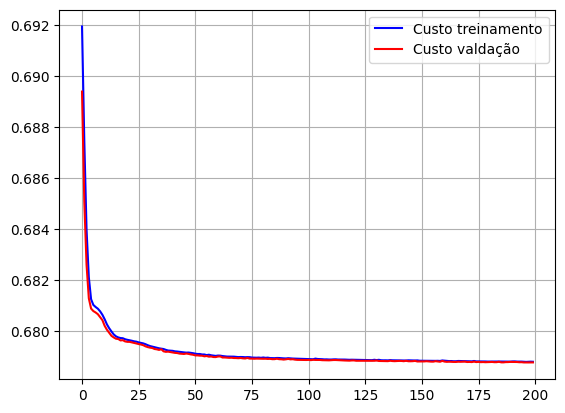

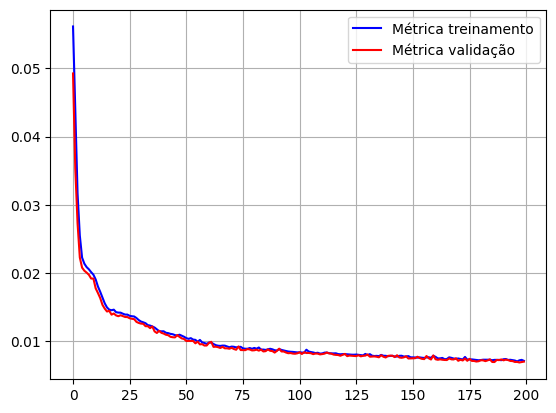

In [ ]:
history = results.history

plt.plot(history["loss"], 'b', label="Custo treinamento")
plt.plot(history["val_loss"], 'r', label="Custo valdação")
plt.legend()
plt.grid()
plt.show()

plt.plot(history["mae"], 'b', label="Métrica treinamento")
plt.plot(history["val_mae"], 'r', label="Métrica validação")
plt.legend()
plt.grid()
plt.show()

- Observe que não aparece problema de overfitting no treinamento.


- O erro de absoluto médio é de cerca de 0.0093, o que é um bom resultado. Porém, como não está ocorrende overfitting poderia testar dimensões maiores para o espaço latente para reduzir esse erro.

### 3.4 Avaliação e teste

Para avaliar o autoencoder vamos fazer o gráfico de exames normais/anormais originais, das suas reconstruções pelo autoencoder e do erro de reconstrução

Gráficos de exames normais.

Exames normais


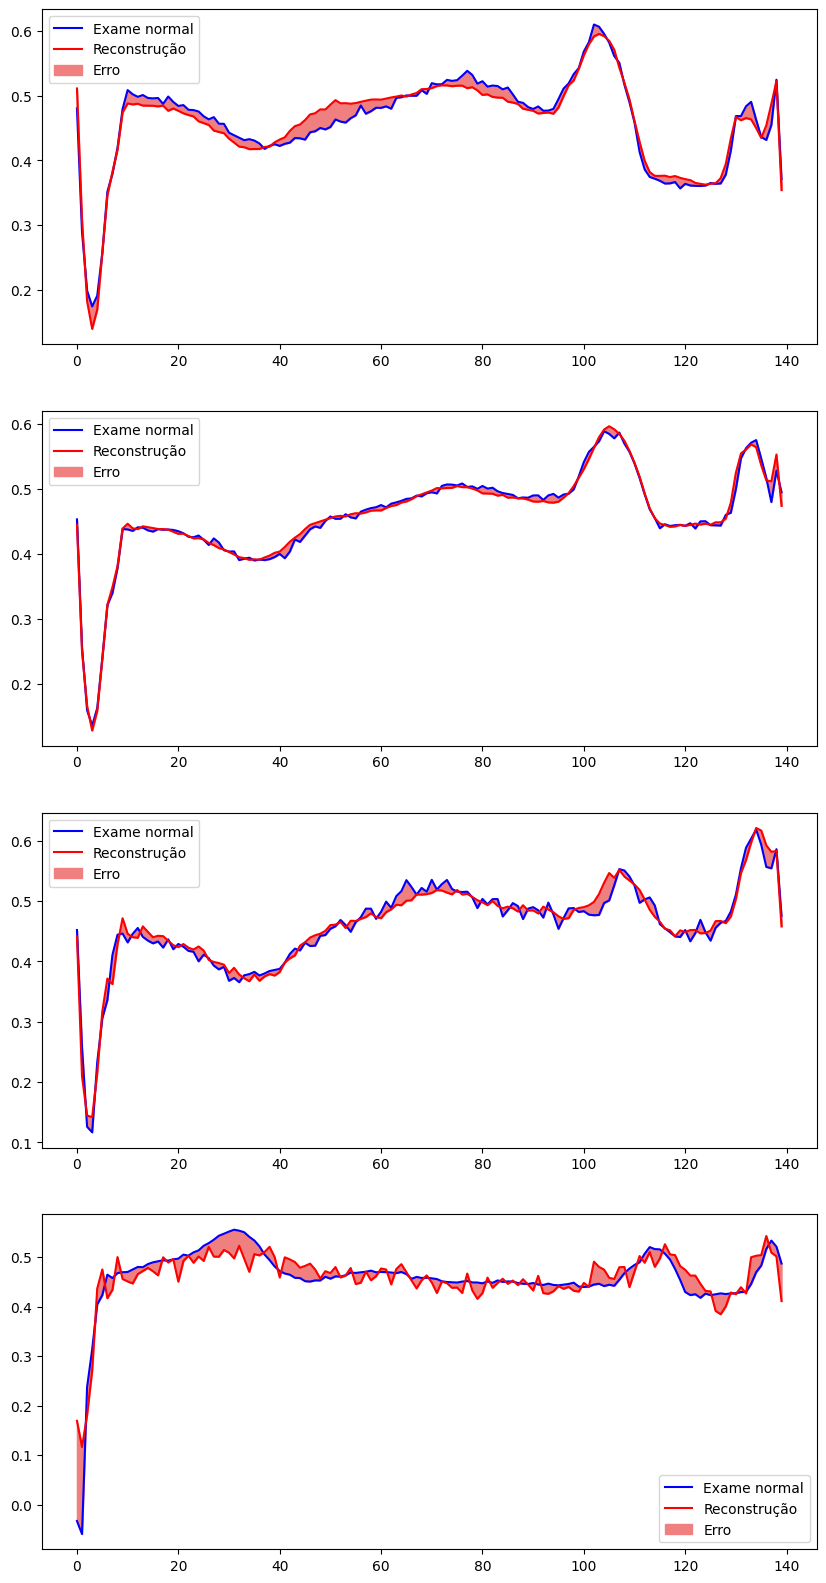

In [ ]:
# Reconstrução de exames normais
code = encoder(x_test_normal).numpy()
exames_rec = decoder(code).numpy()

# Mostra exames normais originais, reconstruídos e erro
print('Exames normais')
f, pos = plt.subplots(4, 1, figsize=(10, 20))
for i in range(4):
    pos[i].plot(x_test_normal[i], 'b')
    pos[i].plot(exames_rec[i], 'r')
    pos[i].fill_between(np.arange(140), exames_rec[i], x_test_normal[i], color='lightcoral' )
    pos[i].legend(labels=["Exame normal", "Reconstrução", "Erro"])
plt.show()

Gráficos de exames com problemas.

Exames com problemas


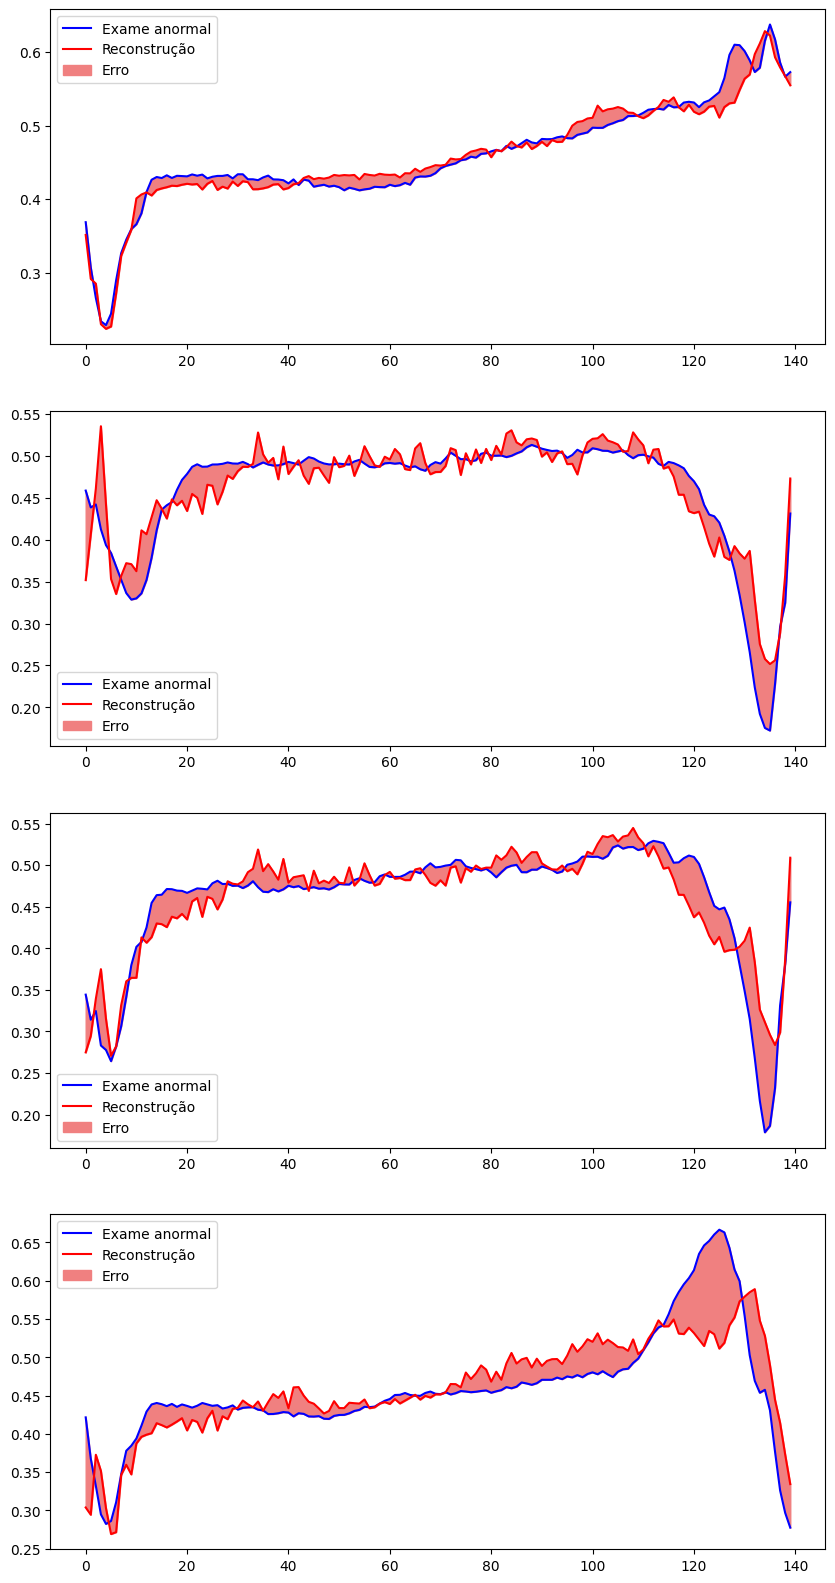

In [ ]:
code = encoder(x_test_anormal).numpy()
exames_rec = decoder(code).numpy()

# Mostra exames normais originais, reconstruídos e erro
print('Exames com problemas')
f, pos = plt.subplots(4, 1, figsize=(10, 20))
for i in range(4):
    pos[i].plot(x_test_anormal[i], 'b')
    pos[i].plot(exames_rec[i], 'r')
    pos[i].fill_between(np.arange(140), exames_rec[i], x_test_anormal[i], color='lightcoral' )
    pos[i].legend(labels=["Exame anormal", "Reconstrução", "Erro"])
plt.show()

- Observe que o erro de reconstrução é bem maior para os casos dos exames com problemas.

### 3.5 Deteção de anomalias

Anomalias nos exames são detectadas se o erro de reconstrução é maior que um determinado limiar.

Vamos usar o erro absoluto médio para calcular o erro de reconstrução e vamos considerar exames como sendo anormais se o erro de reconstrução for maior do que um desvio padrão do conjunto de treinamento.

#### Cálculo do erro de reconstrução dos exames normais

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


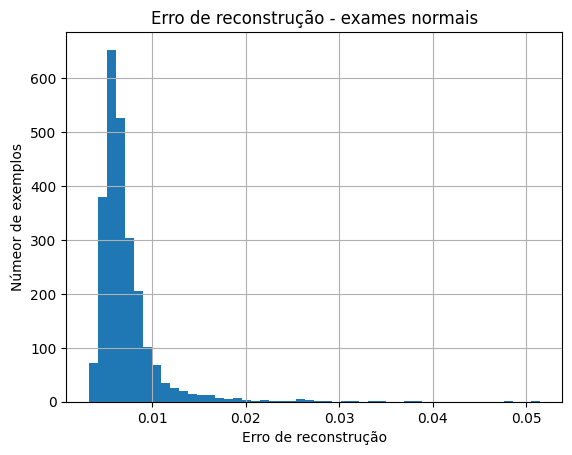

In [ ]:
# Reconstrução dos exames normais
exames_normais_rec = autoencoder.predict(x_train_normal)

# Cálculo do erro de reconstrução dos exames normais
erro_rec_norm = tf.keras.losses.mae(exames_normais_rec, x_train_normal)

# Gráfico do hstograma do erro de reconstrução
plt.title('Erro de reconstrução - exames normais')
plt.hist(erro_rec_norm, bins=50)
plt.xlabel("Erro de reconstrução")
plt.ylabel("Númeor de exemplos")
plt.grid()
plt.show()

#### Cálculo do limiar de normalidade

Vamos calcular o desvio padrão do erro de reconstrução dos exames normais para usar como limiar para identificar anomalias.

In [ ]:
# Calculo do desvio padrão
std = np.std(erro_rec_norm)
mean = np.mean(erro_rec_norm)
print("Desvio padrão: ", std)
print("Média: ", mean)

# Limiar de normalidade
limiar = np.mean(erro_rec_norm) + 2*std
print("Limiar: ", limiar)

Desvio padrão:  0.0035879603
Média:  0.0071765385
Limiar:  0.014352459


Oberve que existem outras estratégias que podem ser usadas para selecionar um valor limite acima do qual os exeames devem ser classificados como anormais $\to$ a abordagem adequada depende do conjunto de dados.

Se forem examinados os erros de reconstrução para os exemplos anormais do conjunto de teste, é possível notar que a maioria tem um erro de reconstrução maior do que o limiar adotado.

Observa-se que Variando o limiar é possível ajustar a "precisão" e a "revocação" do detector de anomalias.


#### Cálculo do erro de reconstrução dos exames anormais

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


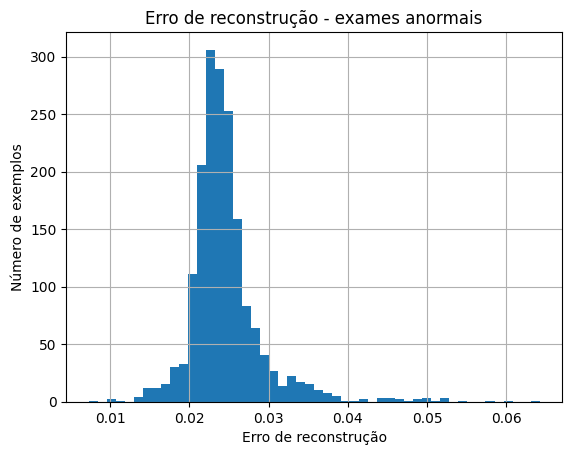

In [ ]:
# Reconstrução dos exames normais
exames_anormais_rec = autoencoder.predict(x_train_anormal)

# Cálculo do erro de reconstrução dos exames anormais
erro_rec = tf.keras.losses.mae(exames_anormais_rec, x_train_anormal)

# Gráfico do hstograma do erro de reconstrução
plt.hist(erro_rec, bins=50)
plt.title('Erro de reconstrução - exames anormais')
plt.xlabel("Erro de reconstrução")
plt.ylabel("Número de exemplos")
plt.grid()
plt.show()

In [ ]:
# Calculo do desvio padrão
std = np.std(erro_rec)
mean = np.mean(erro_rec)
print("Desvio padrão: ", std)
print("Média: ", mean)

Desvio padrão:  0.004794847
Média:  0.024558239


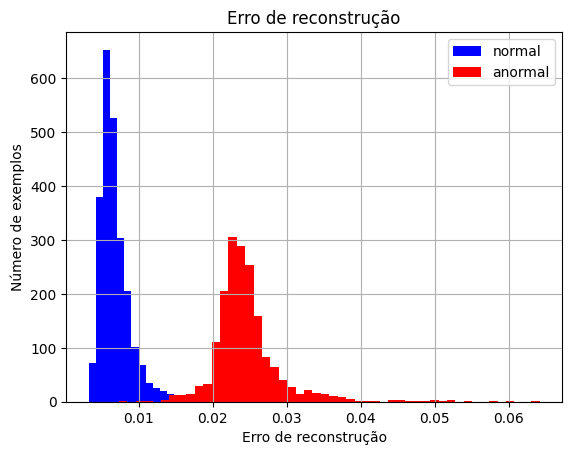

In [ ]:
# Gráfico do hstograma do erro de reconstrução
plt.title('Erro de reconstrução')
plt.hist(erro_rec_norm, bins=50, label='normal', color='b')
plt.hist(erro_rec, bins=50, label='anormal', color='r')
plt.legend()
plt.grid()
plt.xlabel("Erro de reconstrução")
plt.ylabel("Número de exemplos")
plt.show()

- Observe que o erro de reconstrução de particamente todo os exames anormais é maior do que o limiar calculado de 0.01956.


#### Identificação de anomalias

Para identificar anomalias vamos criar uma função (`diagnostico()`) que calcula o erro de reconstrução e o compara com o limiar e retorna o diagnóstico.

In [ ]:
# Importa funçãos da biblioteca SkLearn
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Função para diagnosticar anomalia em exame ECG
def diagnostico(model, data, limiar):
    reconstrucao = model(data)
    erro = tf.keras.losses.mae(reconstrucao, data)
    return tf.math.less(erro, limiar)

# Função para mostrar resultados
def print_stats(prevs, labels):
    print("Exatidão = {}".format(accuracy_score(labels, prevs)))
    print("Precisão = {}".format(precision_score(labels, prevs)))
    print("Revocação = {}".format(recall_score(labels, prevs)))

In [ ]:
prevs = diagnostico(autoencoder, x_test, limiar)
print_stats(prevs, y_test)
print(prevs[:10].numpy())
print(y_test[:10])

Exatidão = 0.9746666666666667
Precisão = 0.9883177570093458
Revocação = 0.9679633867276888
[ True  True  True  True False False  True  True False  True]
[ True False  True  True False  True  True  True False  True]


- A função `tf.math.less(x, y)`, retorna `False` se `y >= x` e `True` se `y < x`.

- As funções `accuracy_score()`, `precision_score()` e `recall_score()` da bilbioteca Sklearn calculam a exatidão, a precisão e a revocação entre dois conjuntos de dados.

## 4. Conclusão

Como vimos, os autoencoders são muito eficientes para realizar alguns tipos de tarefas, tais como: compressão de dados, eliminação de ruídos, restauração de dados, detecção de anomalias e até geração de novos dados de forma limitada.

Um problema dos autoencoders que faz com eles sejam ruins para gerar novos exemplos é que o espaço latente criado por eles contém lacunas e não é possível saber como são os dados gerados nessas lacunas. Isso equivale à falta de dados em um problema de aprendizado supervisionado, pois o modelo não é treinado para essas regiões do espaço latente.

Outro problema dos autoencoders é a separabilidade dentre as regiões do espaço latente que representam cada classe, várias classes ficam bem separadas, mas também existem regiões onde as classes se misturam aleatoriamente, tornando difícil separá-las.

Esses problemas com os autoencoders são resolvidos nos autoencoders variacionais, que aprendem a distribuição de probabilidade dos dados usados no treinamento.